In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output

In [2]:
with open('data_sps_4D.pkl', 'rb') as f:
    data = pickle.load(f)

In [3]:
with open('data_sps_4D_test.pkl', 'rb') as f:
    data_test = pickle.load(f)

In [4]:
data.keys()

dict_keys(['x', 'px', 'y', 'py'])

In [5]:
data_test.keys()

dict_keys(['x', 'px', 'y', 'py'])

In [6]:
data['x'].shape, data['px'].shape, data['y'].shape, data['py'].shape

((10000, 1000), (10000, 1000), (10000, 1000), (10000, 1000))

In [7]:
data_test['x'].shape, data_test['px'].shape, data_test['y'].shape, data_test['py'].shape

((1296, 1000), (1296, 1000), (1296, 1000), (1296, 1000))

Text(0, 0.5, 'y [mm]')

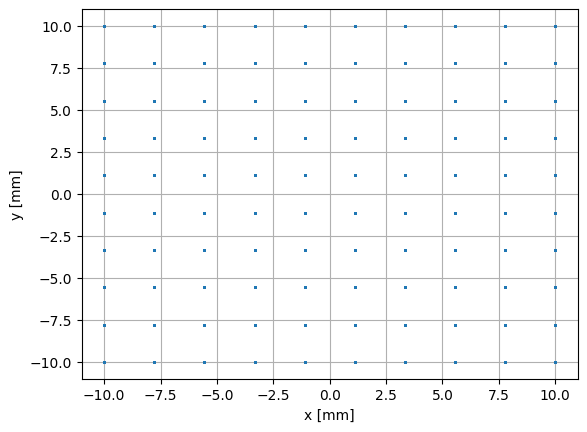

In [8]:
plt.plot(data['x'][:, 0] * 1000, data['y'][:, 0] * 1000, '.', markersize=1, color='C0')
plt.grid()
plt.xlabel('x [mm]')
# plt.ylabel(r'$p_x$')
plt.ylabel('y [mm]')

Text(0, 0.5, 'y [mm]')

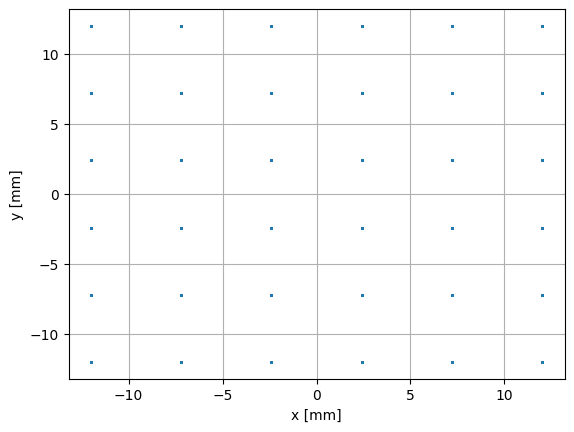

In [9]:
plt.plot(data_test['x'][:, 0] * 1000, data_test['y'][:, 0] * 1000, '.', markersize=1, color='C0')
plt.grid()
plt.xlabel('x [mm]')
# plt.ylabel(r'$p_x$')
plt.ylabel('y [mm]')

In [10]:
import torch
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from models import GSympNet

In [11]:
# Hyperparameters
dim = 4
layers = 9
width = 30
activation = torch.sigmoid
epochs = 1000
batch_size = 64
learning_rate = 1e-3

In [12]:
# # x_xp_data_list = [np.array([data['x'][i, :], data['px'][i, :]]).T for i in range(data['x'].shape[0])]
# x_xp_data_list = [np.array([data['x'][i, :], data['px'][i, :]]).T for i in range(700)]
# x_xp_data = np.vstack(x_xp_data_list)

In [13]:
def min_max_normalize(arr, min_val=None, max_val=None):
    """
    Min-max normalize a numpy array or torch tensor of shape (N, 2) to range [-1, 1].
    If min_val and max_val are not provided, compute from arr along axis=0.
    Returns normalized array, min_val, and max_val.
    """
    if min_val is None:
        min_val = arr.min(axis=0, keepdims=True)
    if max_val is None:
        max_val = arr.max(axis=0, keepdims=True)
    normalized = 2 * (arr - min_val) / (max_val - min_val) - 1
    return normalized, min_val, max_val

def min_max_denormalize(arr, min_val, max_val):
    """
    Denormalize a numpy array or torch tensor of shape (N, 2) from range [-1, 1]
    back to the original range defined by min_val and max_val.
    """
    return (arr + 1) / 2 * (max_val - min_val) + min_val

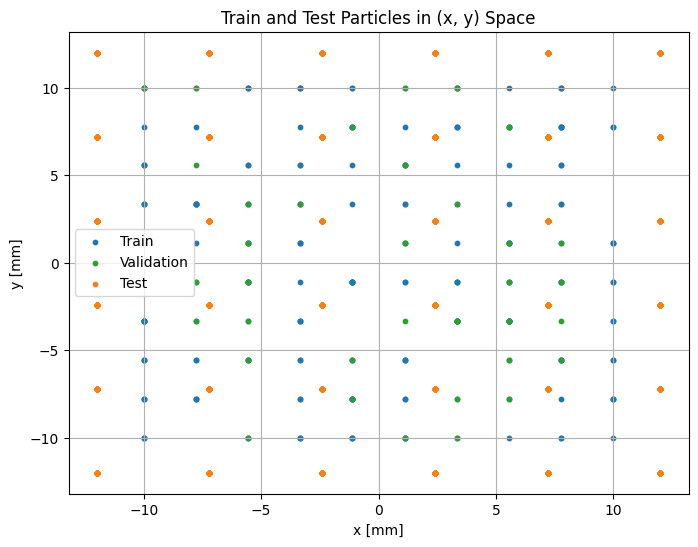

In [14]:
np.random.seed(42)  # For reproducibility

num_particles = data['x'].shape[0]
train_size = 200
val_fraction = 0.2  # 20% for validation
val_size = int(train_size * val_fraction)

# Randomly select indices for training particles
train_indices = np.random.choice(num_particles, size=train_size, replace=False)

# Select val_size number of particles from the remaining indices for validation
remaining_indices = np.setdiff1d(np.arange(num_particles), train_indices)
val_indices = np.random.choice(remaining_indices, size=val_size, replace=False)

# indices to select train particles
x_train = data['x'][train_indices, :]
px_train = data['px'][train_indices, :]
y_train = data['y'][train_indices, :]
py_train = data['py'][train_indices, :]
x_val = data['x'][val_indices, :]
px_val = data['px'][val_indices, :]
y_val = data['y'][val_indices, :]
py_val = data['py'][val_indices, :]

# x_test = data['x'][test_indices, :]
# px_test = data['px'][test_indices, :]
# y_test = data['y'][test_indices, :]
# py_test = data['py'][test_indices, :]

x_test = data_test['x'][:, :]
px_test = data_test['px'][:, :]
y_test = data_test['y'][:, :]
py_test = data_test['py'][:, :]

# Plot the train and test particles in (x, y) space
plt.figure(figsize=(8,6))
plt.scatter(x_train[:, 0] * 1000, y_train[:, 0] * 1000, s=10, color='C0', label='Train')
plt.scatter(x_val[:, 0] * 1000, y_val[:, 0] * 1000, s=10, color='C2', label='Validation')
plt.scatter(x_test[:, 0] * 1000, y_test[:, 0] * 1000, s=10, color='C1', label='Test')
plt.xlabel('x [mm]')
plt.ylabel('y [mm]')
plt.title('Train and Test Particles in (x, y) Space')
plt.legend()
plt.grid()
plt.show()

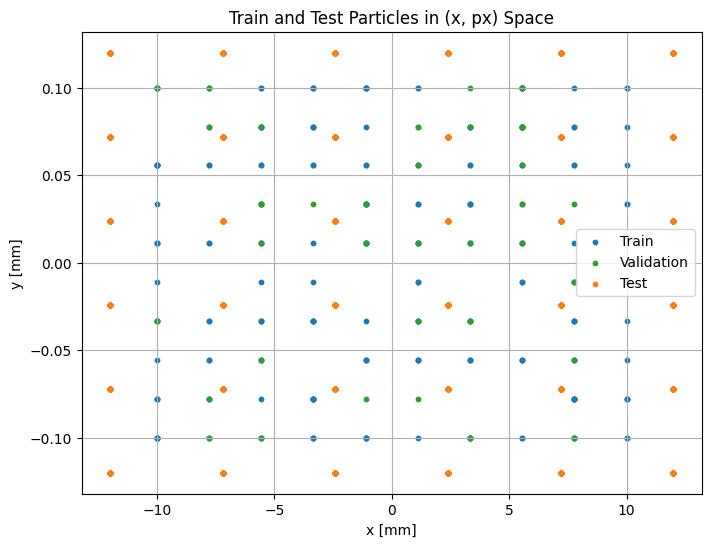

In [15]:
# Plot the train and test particles in (x, px) space
plt.figure(figsize=(8,6))
plt.scatter(x_train[:, 0] * 1000, px_train[:, 0] * 1000, s=10, color='C0', label='Train')
plt.scatter(x_val[:, 0] * 1000, px_val[:, 0] * 1000, s=10, color='C2', label='Validation')
plt.scatter(x_test[:, 0] * 1000, px_test[:, 0] * 1000, s=10, color='C1', label='Test')
plt.xlabel('x [mm]')
plt.ylabel('y [mm]')
plt.title('Train and Test Particles in (x, px) Space')
plt.legend()
plt.grid()
plt.show()

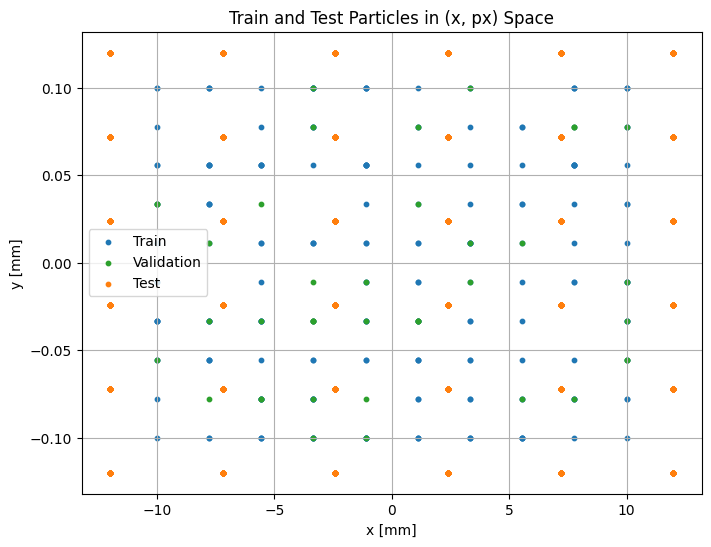

In [16]:
# Plot the train and test particles in (y, py) space
plt.figure(figsize=(8,6))
plt.scatter(y_train[:, 0] * 1000, py_train[:, 0] * 1000, s=10, color='C0', label='Train')
plt.scatter(y_val[:, 0] * 1000, py_val[:, 0] * 1000, s=10, color='C2', label='Validation')
plt.scatter(y_test[:, 0] * 1000, py_test[:, 0] * 1000, s=10, color='C1', label='Test')
plt.xlabel('x [mm]')
plt.ylabel('y [mm]')
plt.title('Train and Test Particles in (x, px) Space')
plt.legend()
plt.grid()
plt.show()

In [17]:
x_train.shape, px_train.shape, x_val.shape, px_val.shape, x_test.shape, px_test.shape, y_train.shape, py_train.shape, y_val.shape, py_val.shape, y_test.shape, py_test.shape

((200, 1000),
 (200, 1000),
 (40, 1000),
 (40, 1000),
 (1296, 1000),
 (1296, 1000),
 (200, 1000),
 (200, 1000),
 (40, 1000),
 (40, 1000),
 (1296, 1000),
 (1296, 1000))

In [18]:
num_turns = 1000
train_data_list = [np.array([x_train[i, :num_turns+1], y_train[i, :num_turns+1], px_train[i, :num_turns+1], py_train[i, :num_turns+1]]).T for i in range(x_train.shape[0])]
train_data = np.vstack(train_data_list)
val_data_list = [np.array([x_val[i, :num_turns+1], y_val[i, :num_turns+1], px_val[i, :num_turns+1], py_val[i, :num_turns+1]]).T for i in range(x_val.shape[0])]
val_data = np.vstack(val_data_list)

In [19]:
train_norm, min, max = min_max_normalize(train_data)
val_norm = min_max_normalize(val_data, min, max)[0]

In [20]:
input, output = train_norm[:-1], train_norm[1:]

In [21]:
input-output

array([[ 0.48726541, -0.03873205, -0.39926553, -0.78682207],
       [-0.09067245,  0.40826228,  0.6221672 ,  0.66864466],
       [-0.35443739, -0.68102432, -0.51326067, -0.38608549],
       ...,
       [ 0.68045881, -0.79654187,  0.03213456,  1.02749471],
       [-0.52974211,  0.20228561,  0.44200671, -1.26546845],
       [ 0.09623575,  0.41298439, -0.68296797,  1.20991236]],
      shape=(199999, 4))

In [22]:
val_norm[:-1] - val_norm[1:]

array([[ 1.05248125,  0.02865255, -0.05288121, -0.48441589],
       [-0.74362779,  0.21095275,  0.76600456,  0.43223506],
       [ 0.03084303, -0.39017259, -1.06426435, -0.27648879],
       ...,
       [-0.11240352,  0.46411279,  0.31411602, -0.04242039],
       [-0.12851493, -0.39101471, -0.30475679,  0.26044225],
       [ 0.30208809,  0.22274233,  0.13168538, -0.41343852]],
      shape=(39999, 4))

In [23]:
train_x = torch.tensor(input, dtype=torch.float32)
train_y = torch.tensor(output, dtype=torch.float32)
val_x = torch.tensor(val_norm[:-1], dtype=torch.float32)
val_y = torch.tensor(val_norm[1:], dtype=torch.float32)

In [24]:
train_x.shape

torch.Size([199999, 4])

In [25]:
val_x.shape

torch.Size([39999, 4])

In [26]:
train_dataset = TensorDataset(train_x, train_y)
val_dataset = TensorDataset(val_x, val_y)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=20, shuffle=False)

In [27]:
model = GSympNet(dim, layers, width, activation)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
criterion = torch.nn.MSELoss()

In [28]:
train_loss_list = []
val_loss_list = []

model.train()

for epoch in range(epochs):
    total_loss = 0.0
    for x_batch, y_batch in train_loader:
        optimizer.zero_grad()
        pred = model(x_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x_batch.size(0)
    avg_loss = total_loss / len(train_dataset)
    train_loss_list.append(avg_loss)
    # print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.10f}")
    
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            pred = model(x_batch)
            loss = criterion(pred, y_batch)
            val_loss += loss.item() * x_batch.size(0)
    avg_val_loss = val_loss / len(val_dataset)
    val_loss_list.append(avg_val_loss)
    print(f"Epoch {epoch+1}/{epochs}, Train Loss: {avg_loss:.10f}, Validation Loss: {avg_val_loss:.10f}")
    
    model.train()
    
    # Real-time plot
    # if (epoch+1) % 1 == 0 or epoch == 0:
    #     clear_output(wait=True)
    #     plt.figure(figsize=(8,4))
    #     # plt.plot(losses)
    #     # plt.ylabel('Loss')
    #     plt.xlabel('Epoch')
    #     plt.plot(np.log10(avg_loss), label='Training Loss', color='C0')
    #     plt.plot(np.log10(avg_val_loss), label='Validation Loss', color='C1', linestyle='--')
    #     plt.ylabel('log10(Loss)')
    #     plt.title('Training Loss')
    #     plt.grid()
    #     plt.show()
        
# Save the list of losses to a file
with open('training_losses1.npy', 'wb') as f:
    np.save(f, np.array(train_loss_list))
    
with open('validation_losses1.npy', 'wb') as f:
    np.save(f, np.array(val_loss_list))

Epoch 1/1000, Train Loss: 0.6653862917, Validation Loss: 0.3220359767
Epoch 2/1000, Train Loss: 0.0568388249, Validation Loss: 0.0012940808
Epoch 3/1000, Train Loss: 0.0014859127, Validation Loss: 0.0009793345
Epoch 4/1000, Train Loss: 0.0010981828, Validation Loss: 0.0007191738
Epoch 5/1000, Train Loss: 0.0009247005, Validation Loss: 0.0006652612
Epoch 6/1000, Train Loss: 0.0008259514, Validation Loss: 0.0006020397
Epoch 7/1000, Train Loss: 0.0007611161, Validation Loss: 0.0005746798
Epoch 8/1000, Train Loss: 0.0007115240, Validation Loss: 0.0005150794
Epoch 9/1000, Train Loss: 0.0006716246, Validation Loss: 0.0005054374
Epoch 10/1000, Train Loss: 0.0006358755, Validation Loss: 0.0004707320
Epoch 11/1000, Train Loss: 0.0006015364, Validation Loss: 0.0004448005
Epoch 12/1000, Train Loss: 0.0005691416, Validation Loss: 0.0004245241
Epoch 13/1000, Train Loss: 0.0005447545, Validation Loss: 0.0004090018
Epoch 14/1000, Train Loss: 0.0005268599, Validation Loss: 0.0003993607
Epoch 15/1000, 

In [29]:
torch.save(model.state_dict(),'sympnet_model_multiparticle_xy_fin1.pt')

In [ ]:
# Re-instantiate the model and load the saved weights
model = GSympNet(dim, layers, width, activation)
model.load_state_dict(torch.load('sympnet_model_multiparticle_xy_fin1.pt'))

<All keys matched successfully>

In [30]:
init_test = np.array([x_test[:, 0], y_test[:,0], px_test[:, 0], py_test[:,0]]).T

In [31]:
# x_xp_init_test = np.array([data['x'][index, 700], data['px'][index, 700]]).T

In [32]:
# x_xp_init_test = x_xp_init_test.reshape(1, 2)
init_test.shape, init_test.dtype

((1296, 4), dtype('float64'))

In [33]:
min.dtype

dtype('float64')

In [34]:
init_test_norm = min_max_normalize(init_test, min, max)[0]

In [35]:
init_test_tensor = torch.tensor(init_test_norm, dtype=torch.float32)

In [36]:
# x_xp_init_test_tensor = x_xp_init_test_tensor.unsqueeze(0)  # Add batch dimension
init_test_tensor.shape

torch.Size([1296, 4])

In [37]:
pred_init = model.predict(init_test_tensor, steps=999)

In [38]:
x_test.shape

(1296, 1000)

In [39]:
test = np.array([x_test[:, 1:], y_test[:, 1:], px_test[:, 1:], py_test[:, 1:]]).T

In [40]:
pred = min_max_denormalize(pred_init.detach().numpy(), min, max)

In [41]:
test.shape, pred.shape

((999, 1296, 4), (1296, 999, 4))

Text(0, 0.5, '$p_x$')

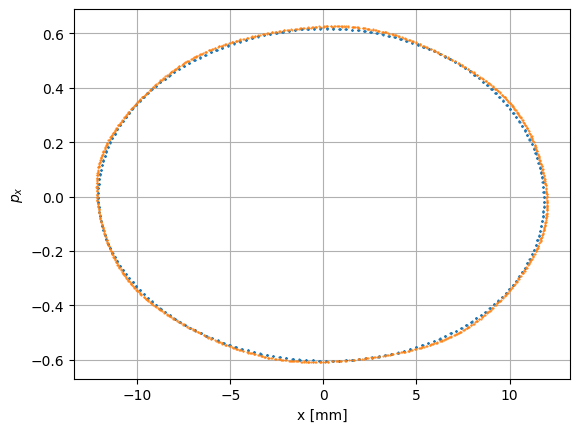

In [42]:
index = 50
plt.plot(test[:, index, 0] * 1000, test[:, index, 2] * 1000, '.', markersize=1, color='C0')
plt.plot(pred[index, :, 0] * 1000, pred[index, :, 2] * 1000, '.', markersize=1, color='C1')
plt.grid()
plt.xlabel('x [mm]')
plt.ylabel(r'$p_x$')

Text(0, 0.5, '$p_y$')

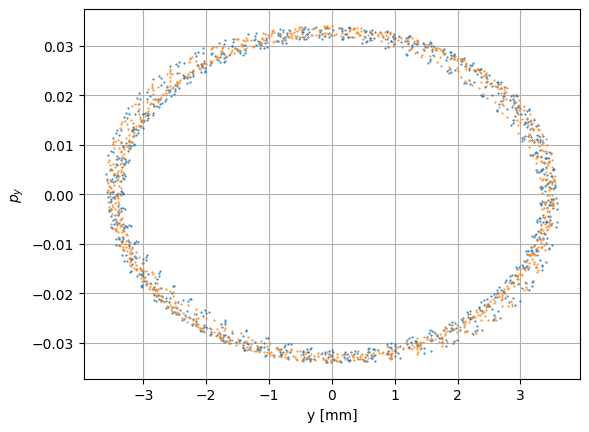

In [43]:
plt.plot(test[:, index, 1] * 1000, test[:, index, 3] * 1000, '.', markersize=1, color='C0')
plt.plot(pred[index, :, 1] * 1000, pred[index, :, 3] * 1000, '.', markersize=1, color='C1')
plt.grid()
plt.xlabel('y [mm]')
plt.ylabel(r'$p_y$')

In [84]:
# Plot position and momentum over turns

def compare_pred_act_x(index, turns):
    plt.figure(figsize=(12, 5))
    plt.subplot(2, 1, 1)
    plt.plot(test[turns, index, 0], label='x', color='C0')
    plt.plot(pred[index, turns, 0].squeeze(), label='Predicted x', linestyle='--', color='C1')
    tick_locs = np.arange(0, len(turns), 10)
    plt.xticks(ticks=tick_locs, labels=turns[tick_locs])
    plt.title(f'Particle {index} Position Over Turns')
    plt.ylabel('x')
    plt.grid()
    plt.legend()

    plt.subplot(2, 1, 2)
    plt.plot(test[turns, index, 2], label='px', color='C0')
    plt.plot(pred[index, turns, 2].squeeze(), label='Predicted px', linestyle='--', color='C1')
    tick_locs = np.arange(0, len(turns), 10)
    plt.xticks(ticks=tick_locs, labels=turns[tick_locs])
    plt.title(f'Particle {index} Momentum Over Turns')
    plt.xlabel('Turn')
    plt.ylabel('px')
    plt.grid()
    plt.legend()
    plt.tight_layout()
    plt.show()

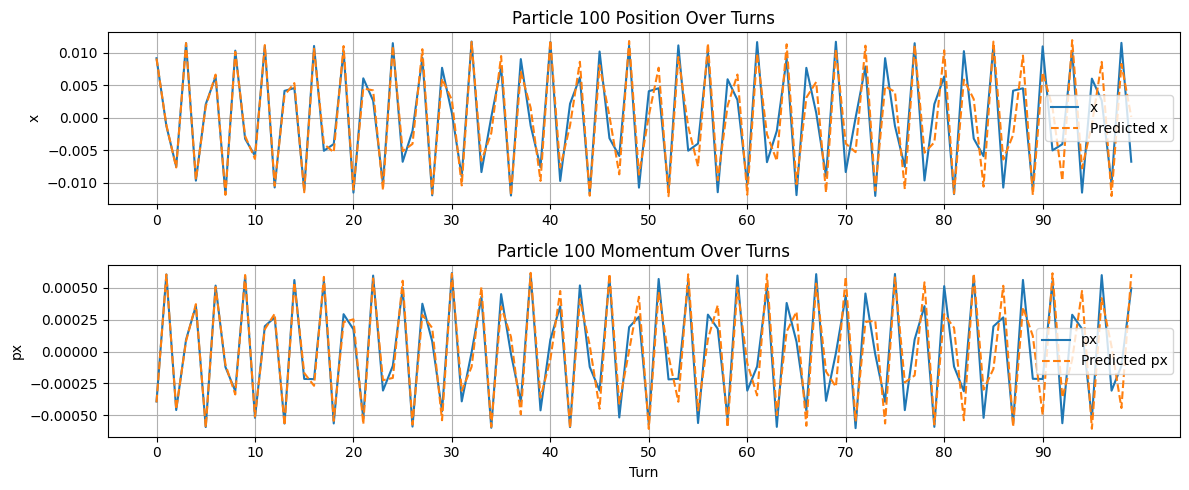

In [85]:
index = 100  # Change this to visualize different particles
turns = np.arange(100)

compare_pred_act_x(index, turns)

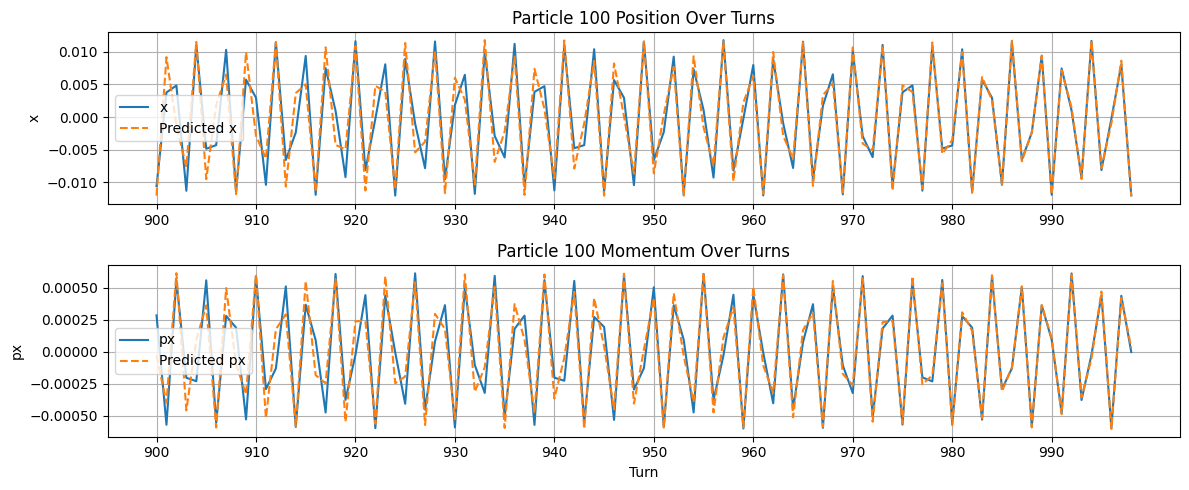

In [86]:
index = 100  # Change this to visualize different particles
turns = np.arange(900, 999)

compare_pred_act_x(index, turns)

In [98]:
def x_px_turns(turns_to_plot, index):
    fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharex=True, sharey=True)
    for i, turn in enumerate(turns_to_plot):
        ax = axes[i // 5, i % 5]
        ax.plot(test[:, index, 0] * 1000, test[:, index, 2] * 1000, '.', markersize=1, color='C0', label='True')
        ax.plot(pred[index, :, 0] * 1000, pred[index, :, 2] * 1000, '.', markersize=1, color='C1', label='Predicted')
        ax.plot(test[turn, index, 0] * 1000, test[turn, index, 2] * 1000, 'o', markersize=10, color='C2', label=f'True: Particle {index}')
        ax.plot(pred[index, turn, 0] * 1000, pred[index, turn, 2] * 1000, 'o', markersize=10, color='C3', label=f'Predicted: Particle {index}')
        ax.set_title(f'Turn {turn+1}')
        ax.grid(True)
        if i % 5 == 0:
            ax.set_ylabel(r'$p_x$ [mm]')
        if i >= 5:
            ax.set_xlabel('x [mm]')

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper right')
    plt.tight_layout()
    plt.show()

In [99]:
def y_py_turns(turns_to_plot, index):
    fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharex=True, sharey=True)
    for i, turn in enumerate(turns_to_plot):
        ax = axes[i // 5, i % 5]
        ax.plot(test[:, index, 1] * 1000, test[:, index, 3] * 1000, '.', markersize=1, color='C0', label='True')
        ax.plot(pred[index, :, 1] * 1000, pred[index, :, 3] * 1000, '.', markersize=1, color='C1', label='Predicted')
        ax.plot(test[turn, index, 1] * 1000, test[turn, index, 3] * 1000, 'o', markersize=10, color='C2', label=f'True: Particle {index}')
        ax.plot(pred[index, turn, 1] * 1000, pred[index, turn, 3] * 1000, 'o', markersize=10, color='C3', label=f'Predicted: Particle {index}')
        ax.set_title(f'Turn {turn+1}')
        ax.grid(True)
        if i % 5 == 0:
            ax.set_ylabel(r'$p_y$ [mm]')
        if i >= 5:
            ax.set_xlabel('y [mm]')

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper right')
    plt.tight_layout()
    plt.show()

In [100]:
def init_state_x_px(indices_to_label):
    plt.figure(figsize=(8, 6))
    plt.scatter(init_test[:, 0], init_test[:, 2], s=10, color='C0')

# indices_to_label = range(700,900)
    for idx in indices_to_label:
        plt.annotate(str(idx), (init_test[idx, 0], init_test[idx, 2]), fontsize=8, color='red')

    plt.xlabel('x')
    plt.ylabel('px')
    plt.title('Particles in (x, px) space - initial state')
    plt.grid()
    plt.show()

In [101]:
def init_state_y_py(indices_to_label):
    plt.figure(figsize=(8, 6))
    plt.scatter(init_test[:, 1], init_test[:, 3], s=10, color='C0')

# indices_to_label = range(700,900)
    for idx in indices_to_label:
        plt.annotate(str(idx), (init_test[idx, 1], init_test[idx, 3]), fontsize=8, color='red')

    plt.xlabel('y')
    plt.ylabel('py')
    plt.title('Particles in (y, py) space - initial state')
    plt.grid()
    plt.show()

In [102]:
turns_to_plot = np.arange(0, 1000, 100)

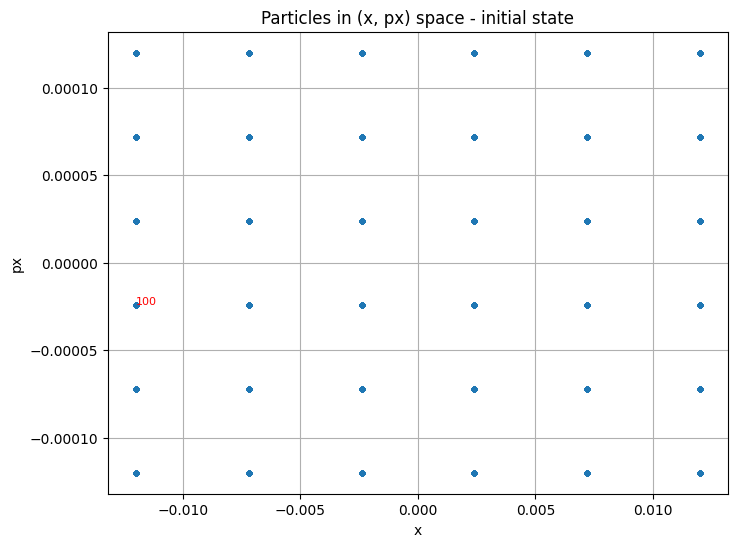

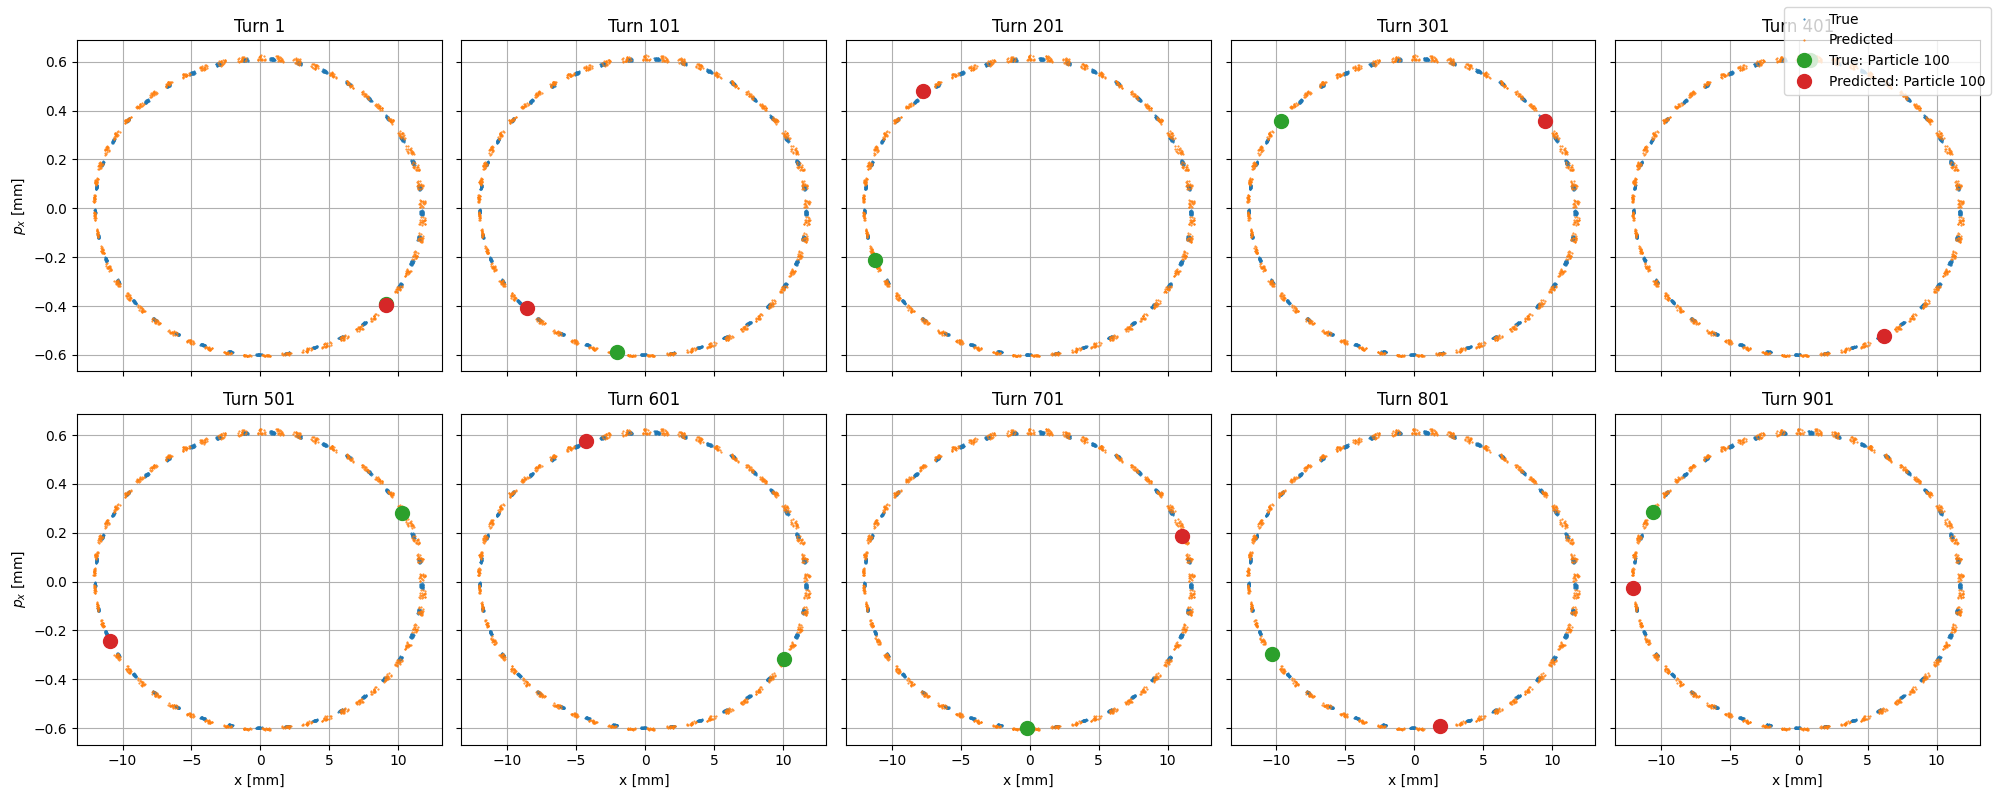

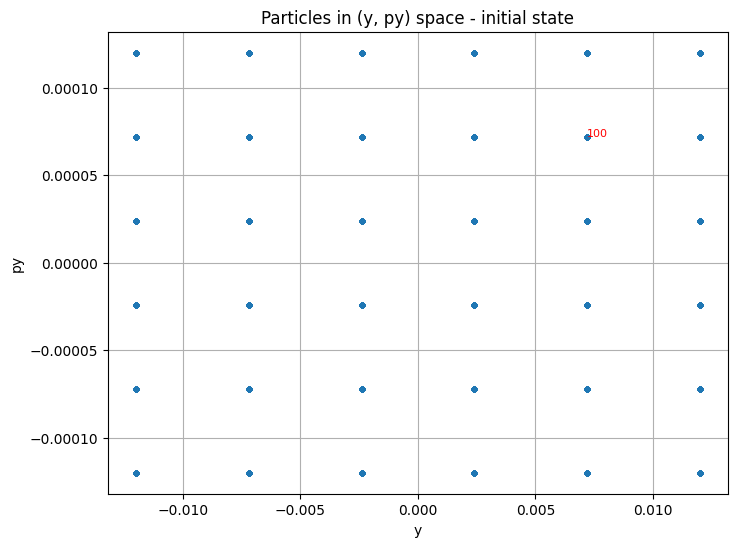

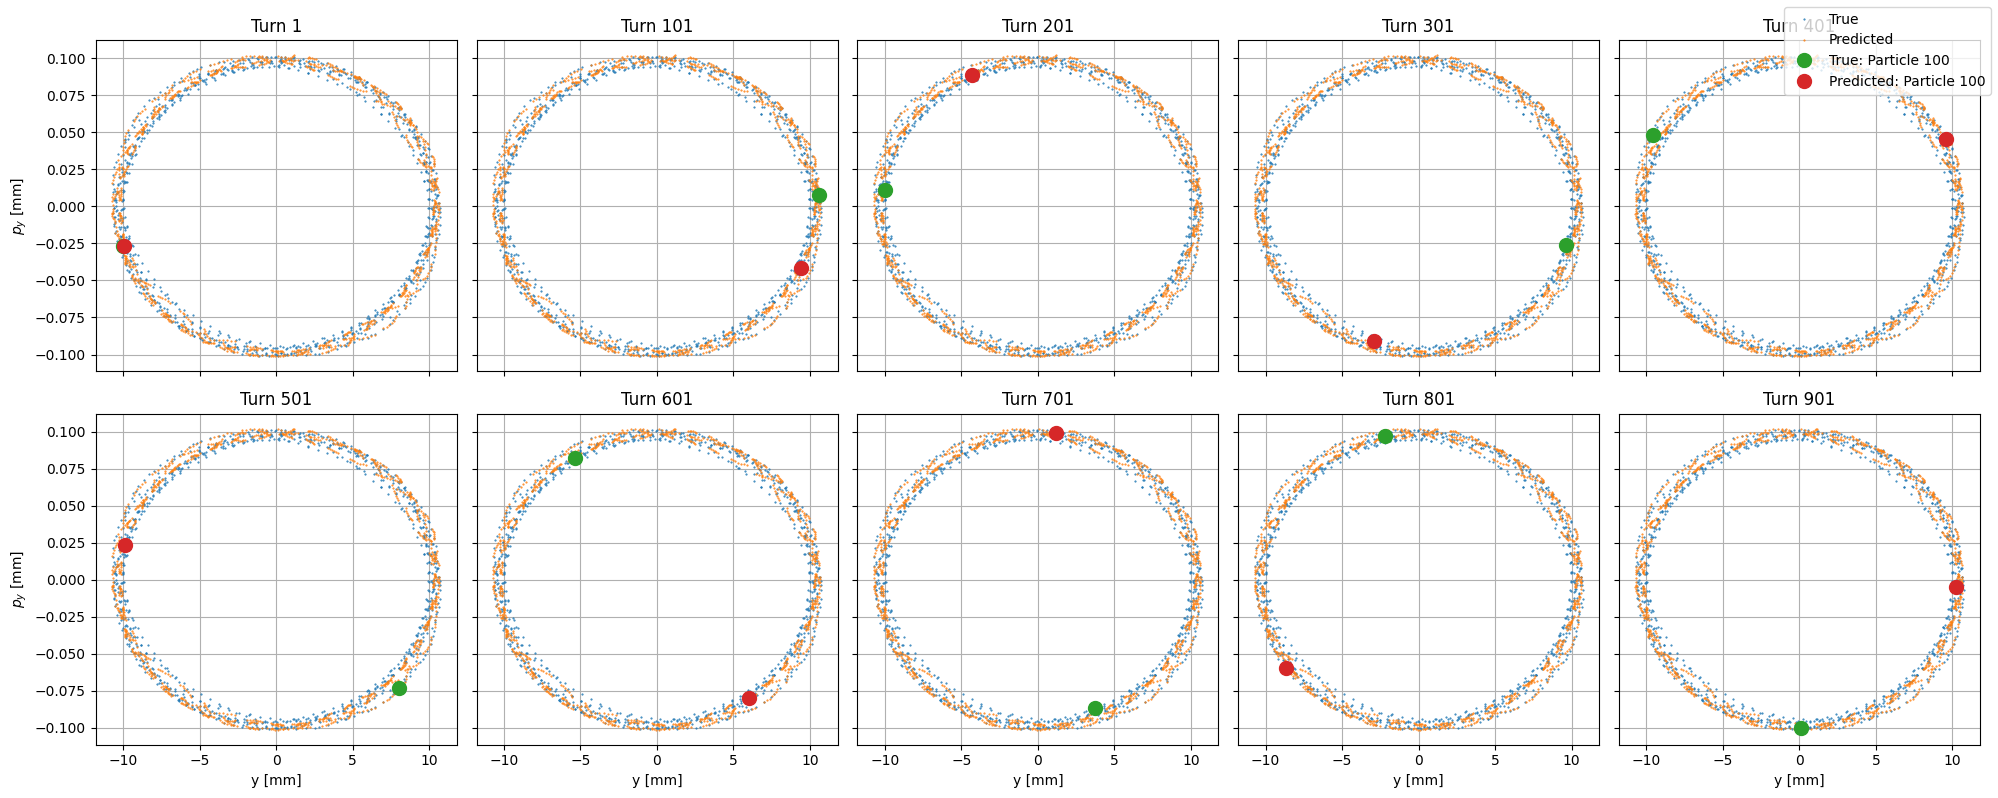

In [103]:
indices_to_label = [100] # indices to label

init_state_x_px(indices_to_label)
x_px_turns(turns_to_plot, indices_to_label[0])

init_state_y_py(indices_to_label)
y_py_turns(turns_to_plot, indices_to_label[0])

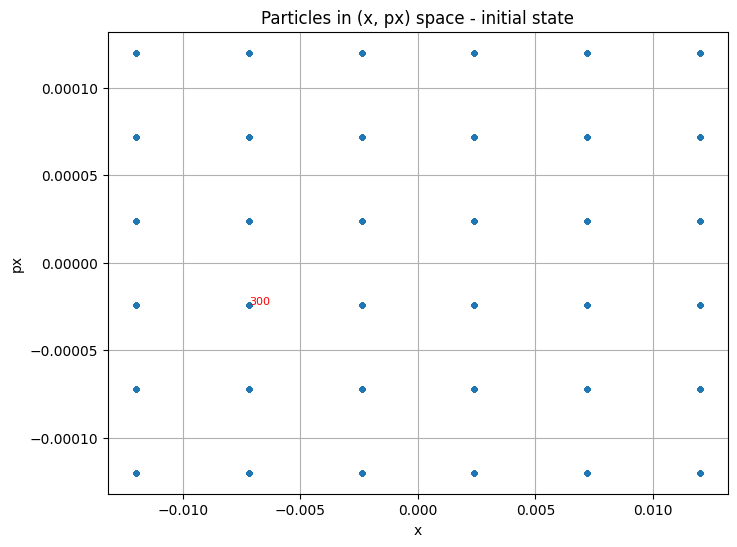

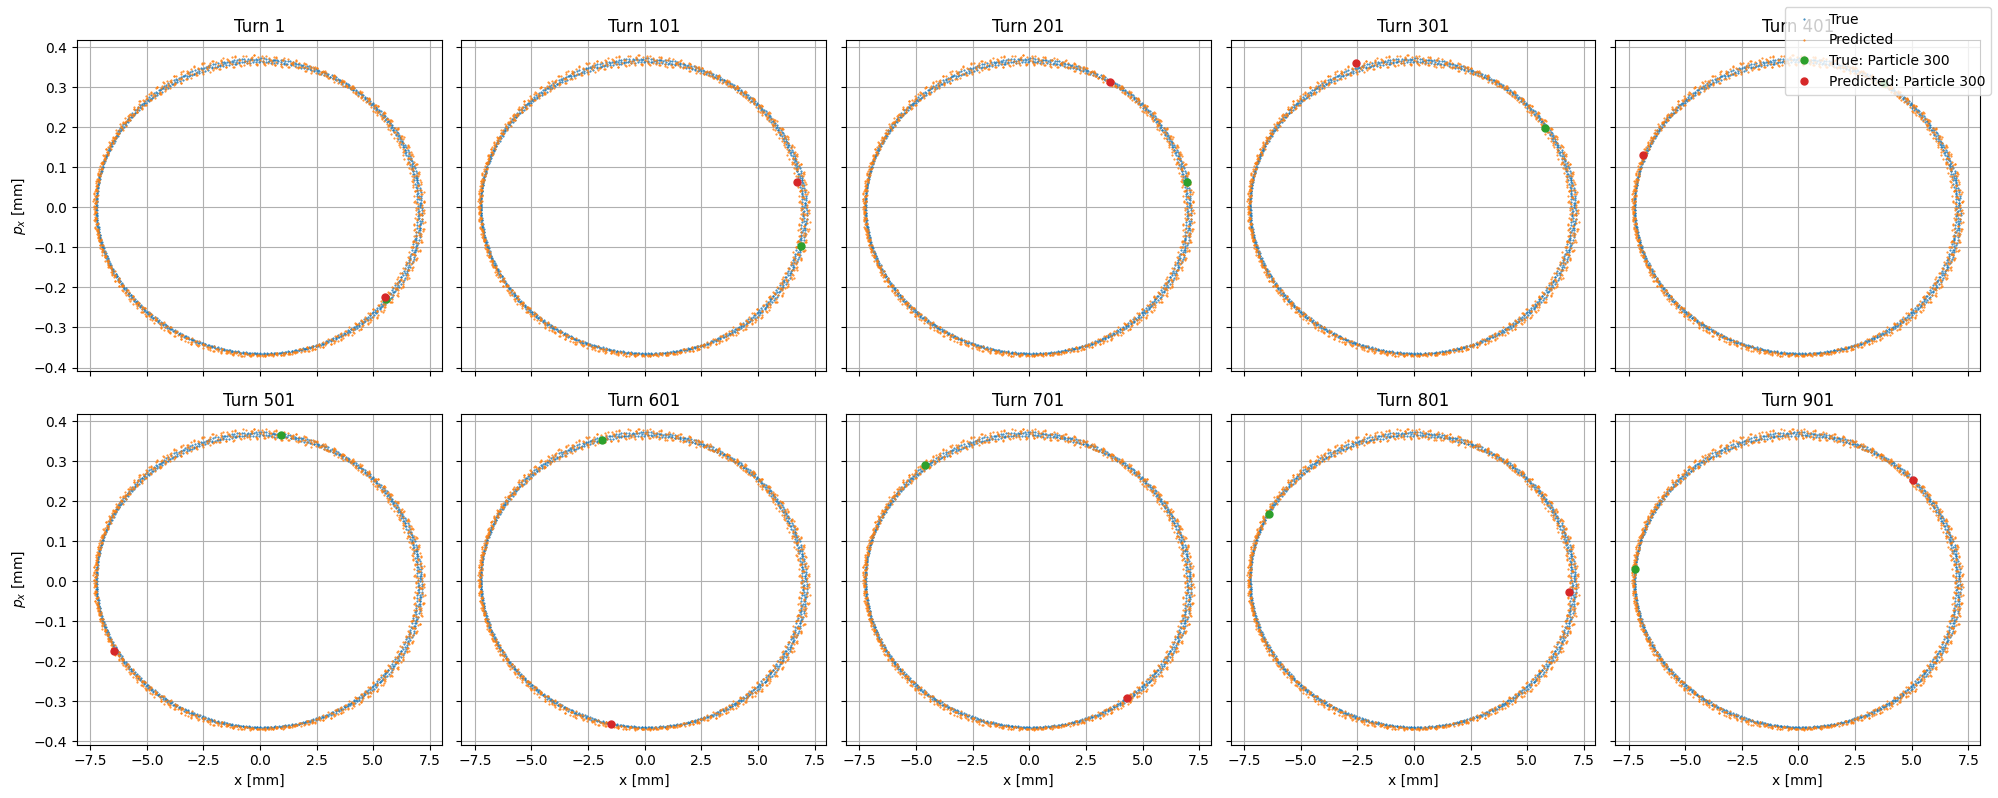

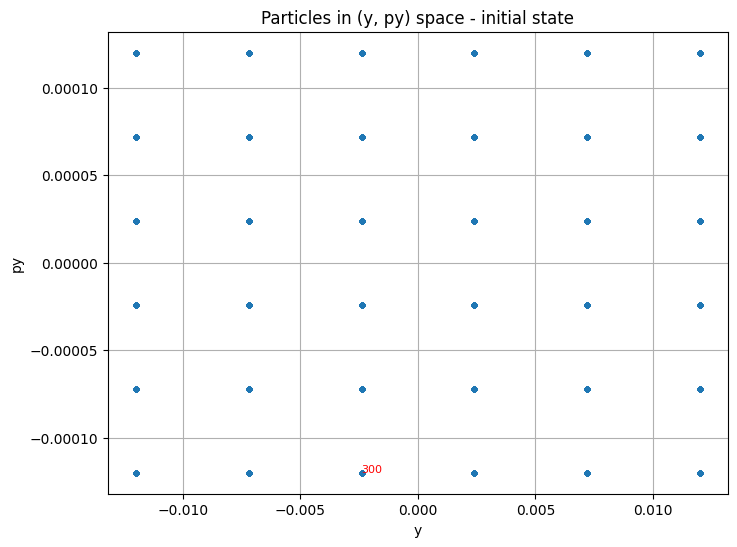

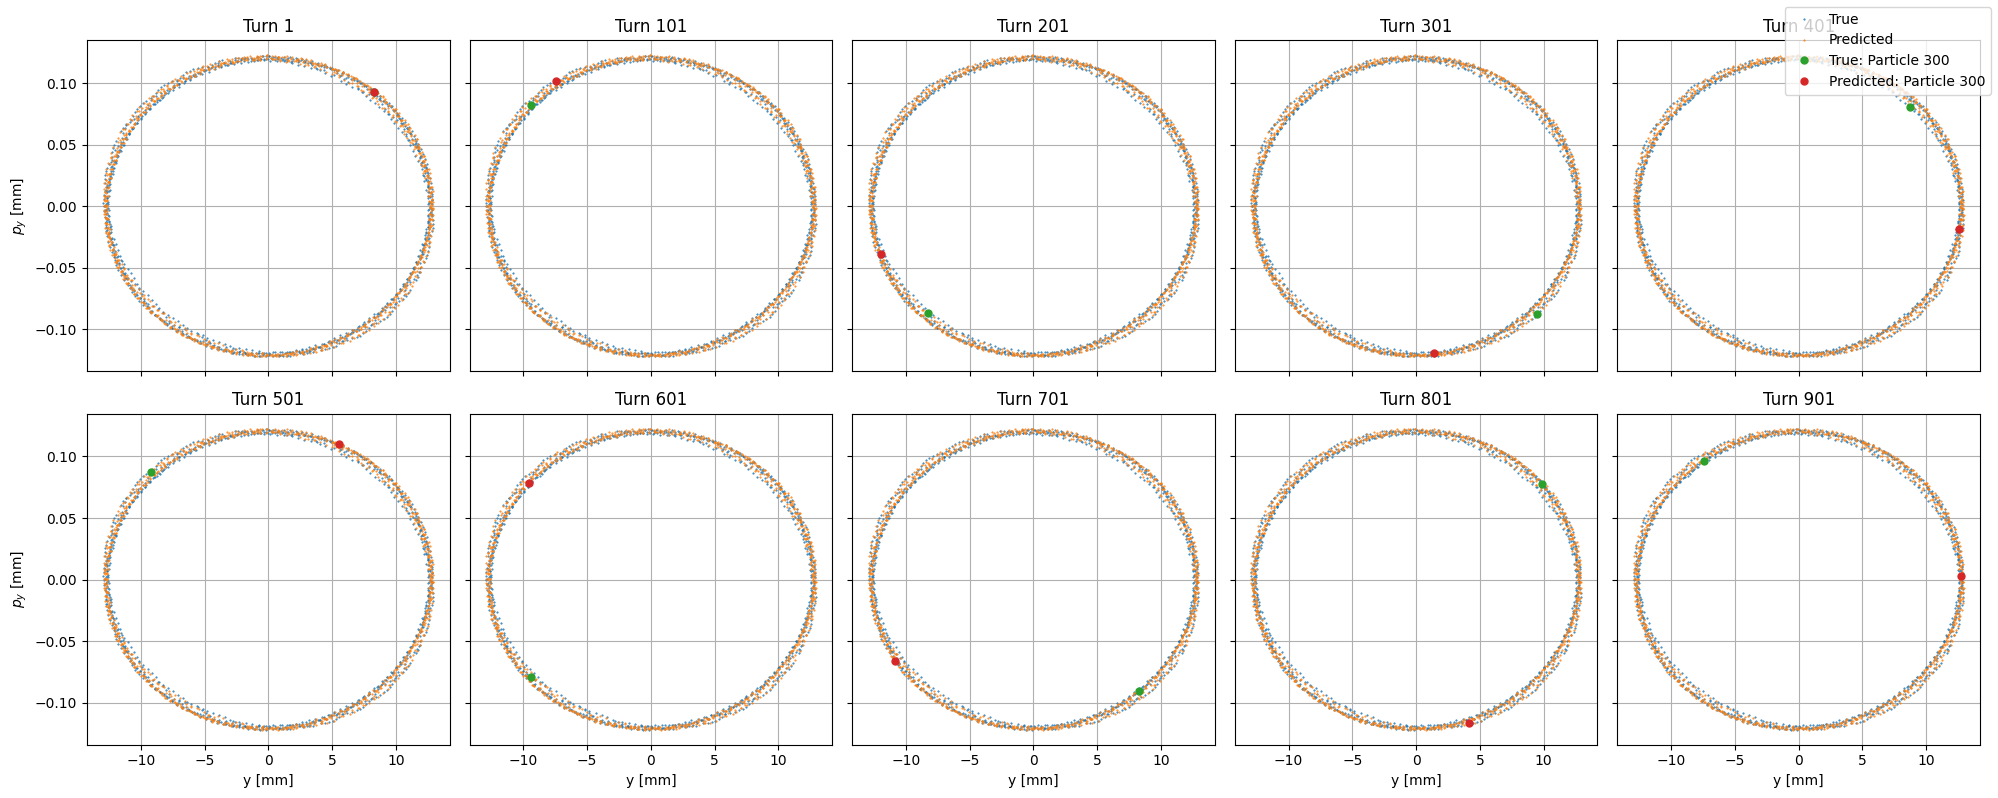

In [95]:
indices_to_label = [300] # indices to label

init_state_x_px(indices_to_label)
x_px_turns(turns_to_plot, indices_to_label[0])

init_state_y_py(indices_to_label)
y_py_turns(turns_to_plot, indices_to_label[0])

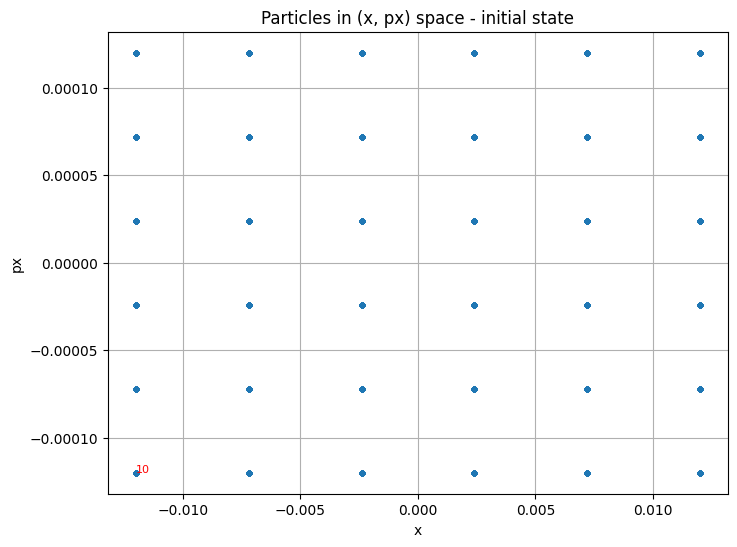

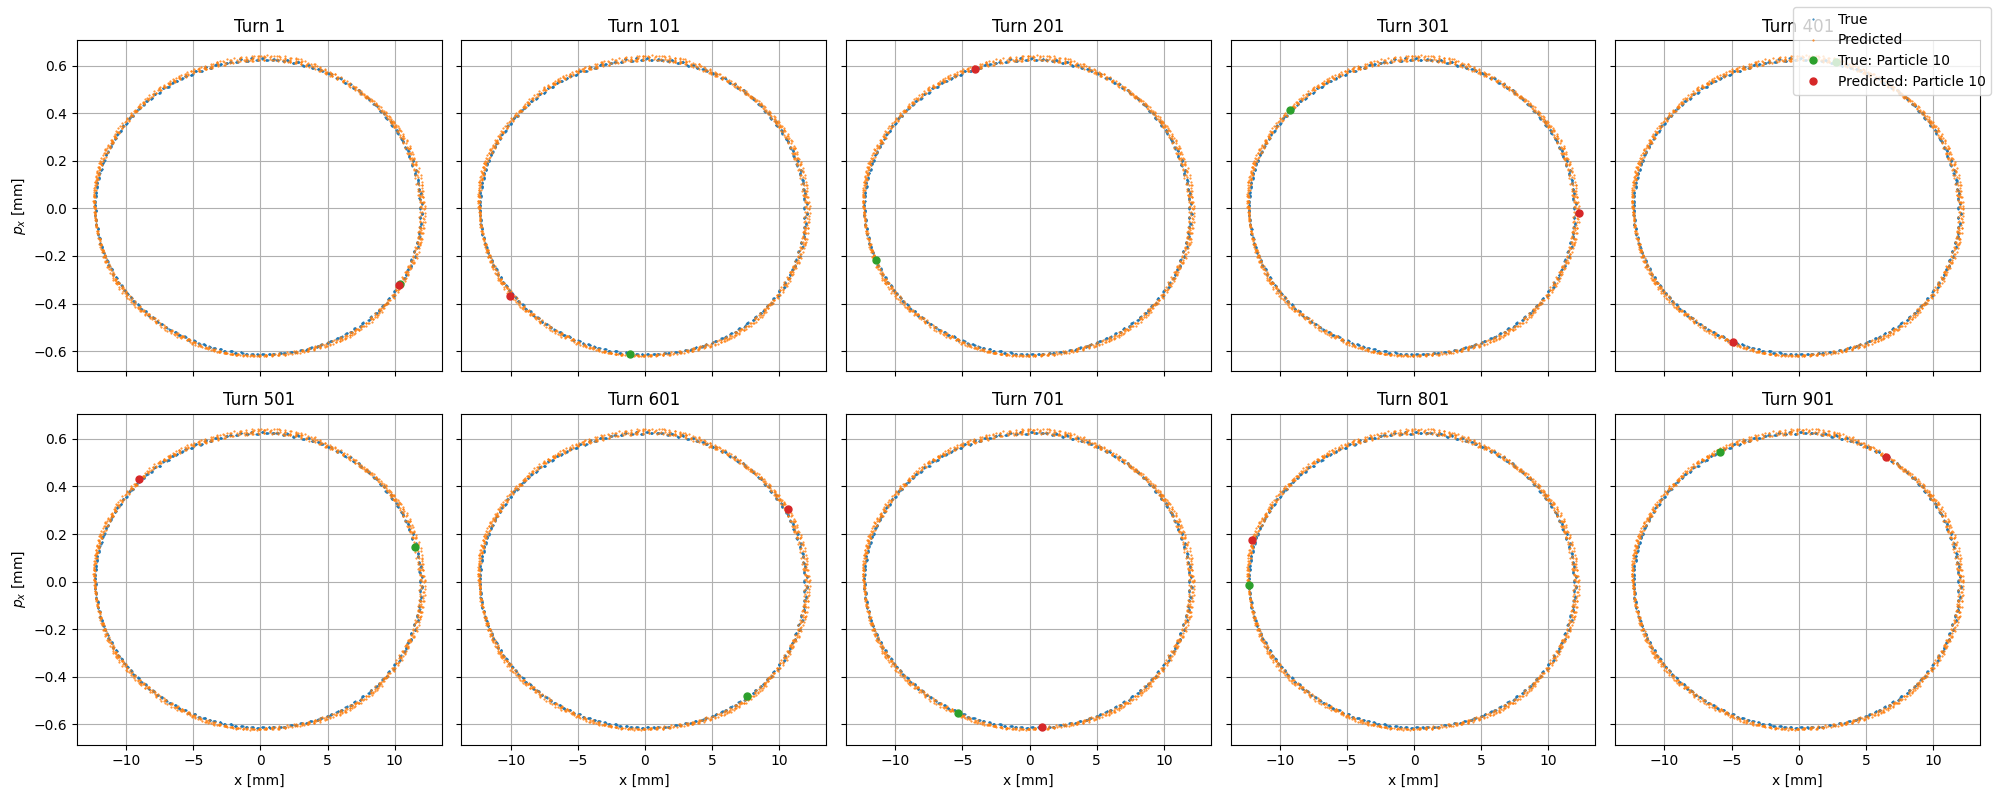

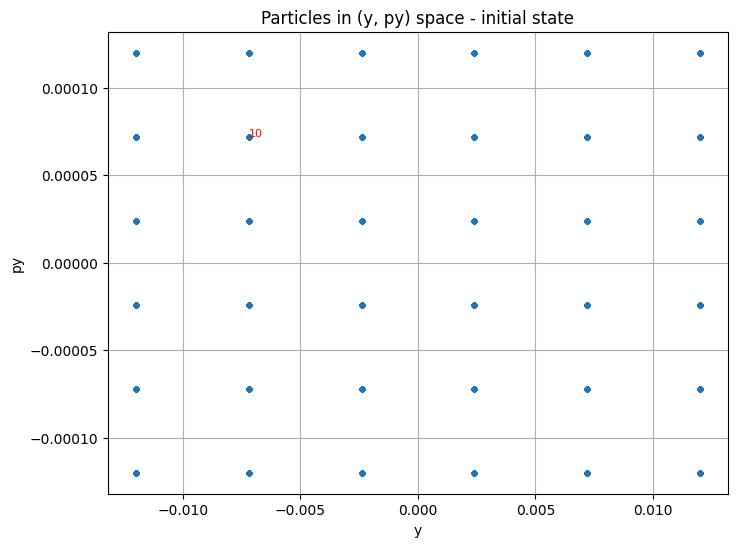

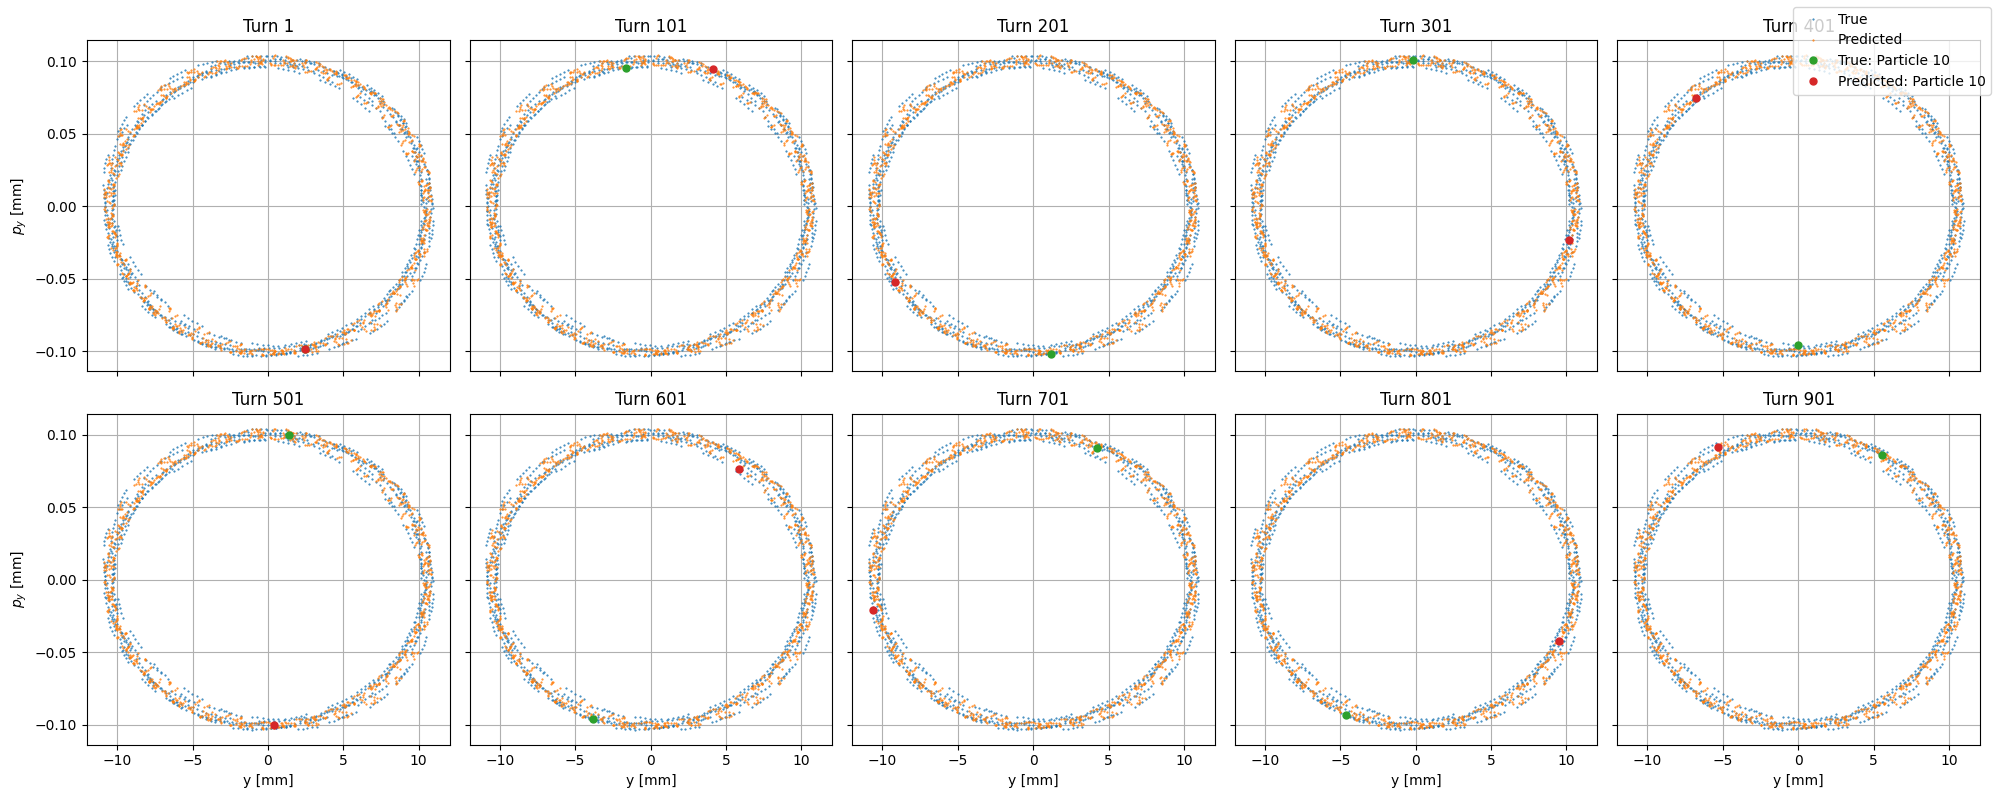

In [96]:
indices_to_label = [10] # indices to label

init_state_x_px(indices_to_label)
x_px_turns(turns_to_plot, indices_to_label[0])

init_state_y_py(indices_to_label)
y_py_turns(turns_to_plot, indices_to_label[0])

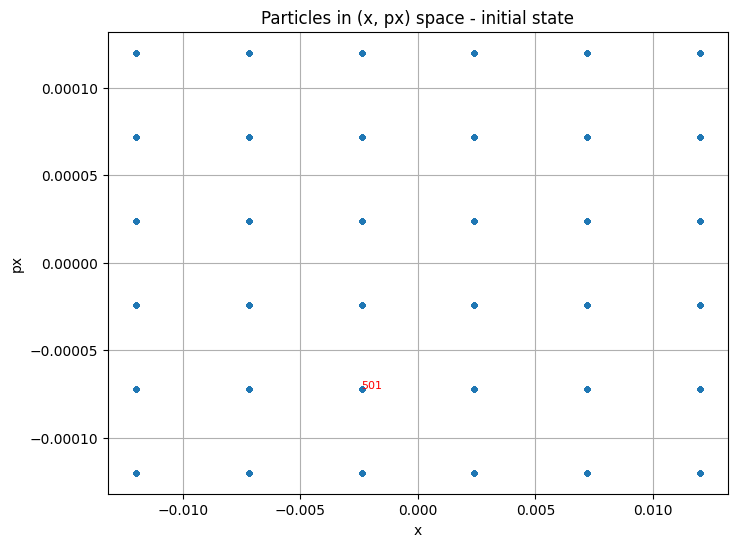

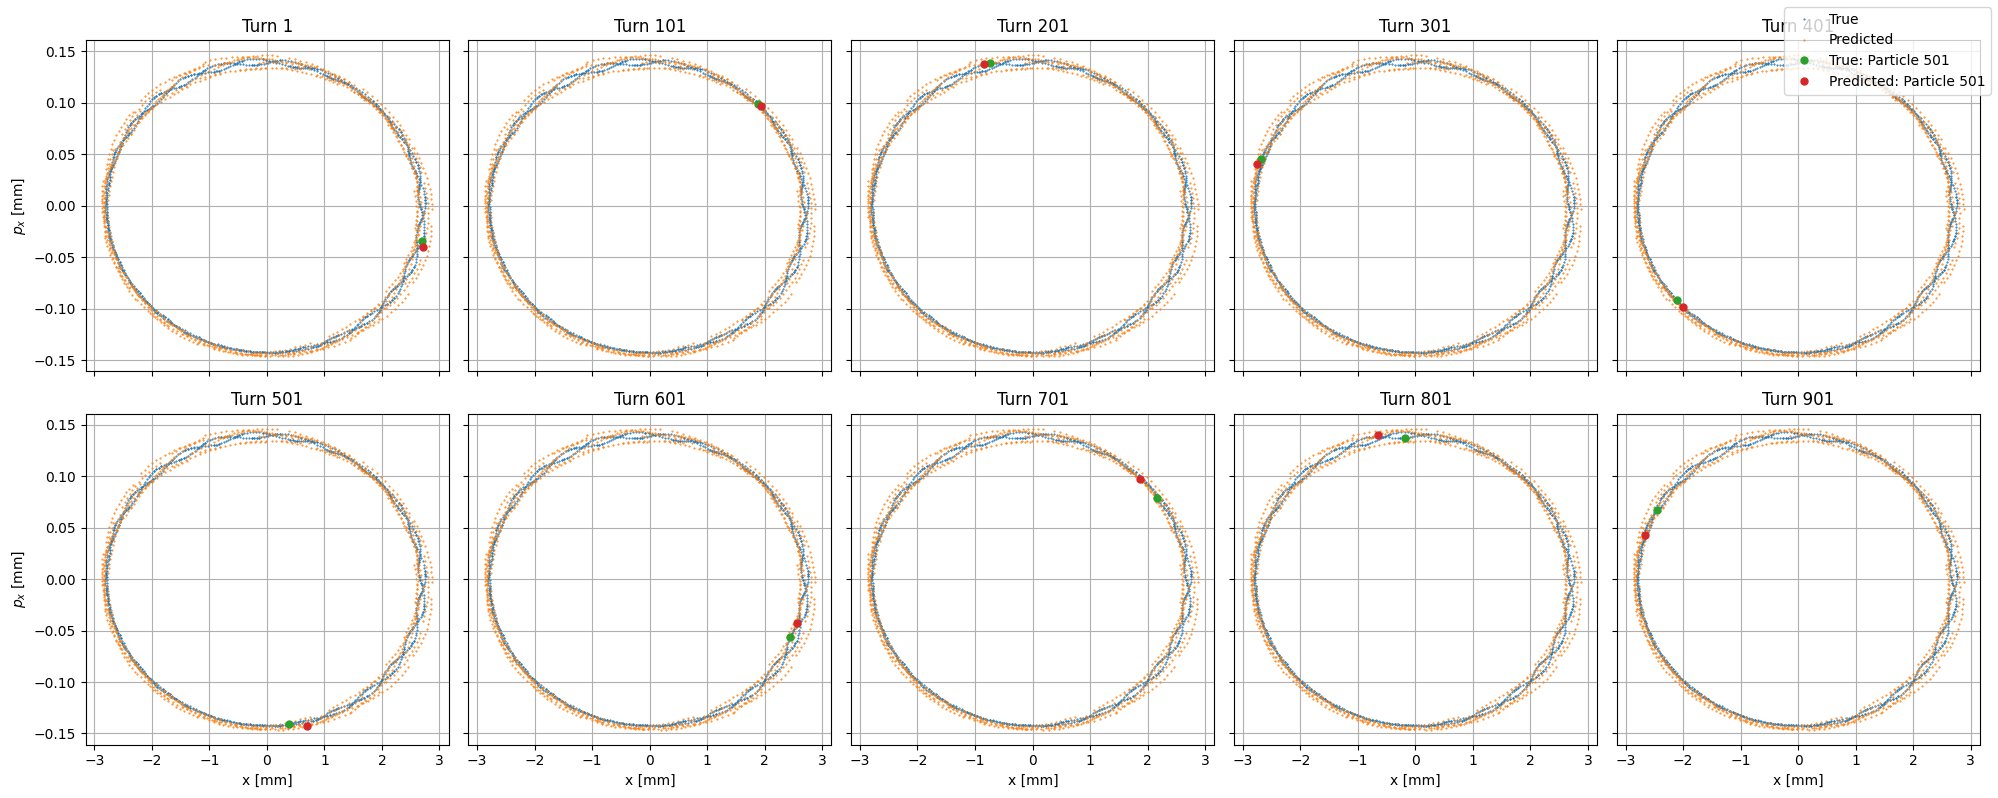

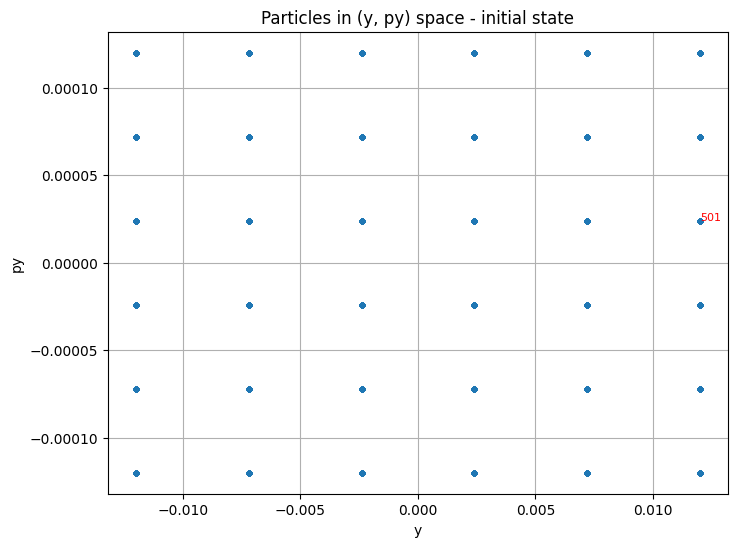

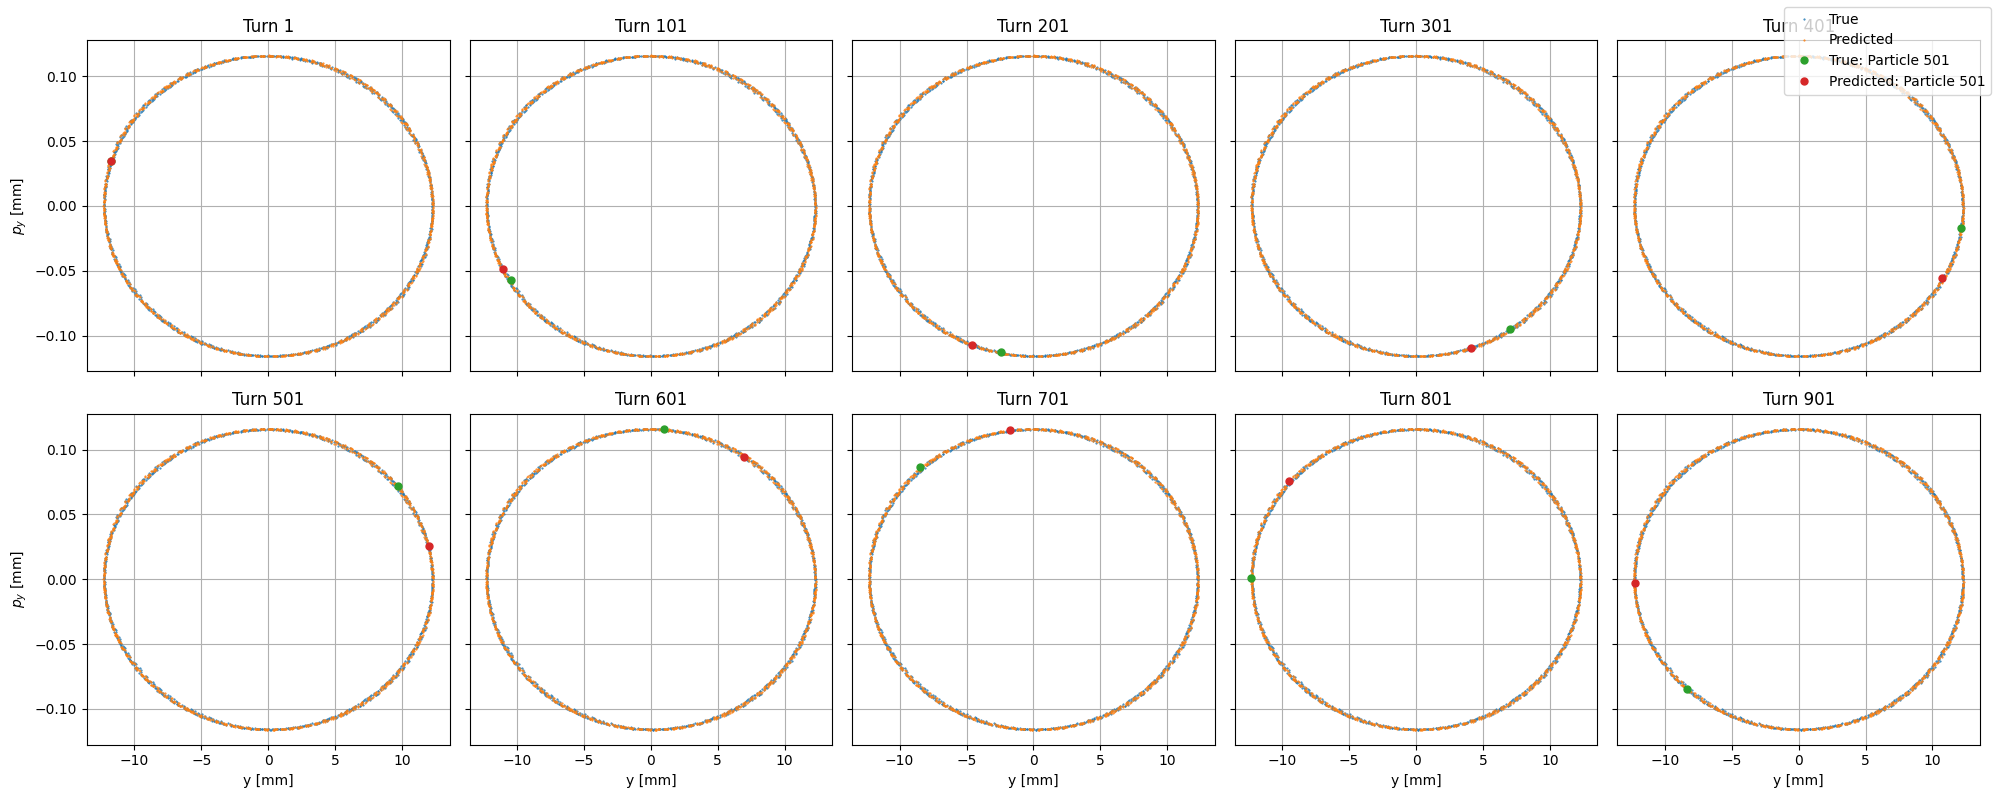

In [97]:
indices_to_label = [501] # indices to label

init_state_x_px(indices_to_label)
x_px_turns(turns_to_plot, indices_to_label[0])

init_state_y_py(indices_to_label)
y_py_turns(turns_to_plot, indices_to_label[0])

In [79]:
# Plot position and momentum over turns
def compare_pred_act_y(index, turns):
    plt.figure(figsize=(12, 5))
    plt.subplot(2, 1, 1)
    plt.plot(test[turns, index, 1], label='y', color='C0')
    plt.plot(pred[index, turns, 1].squeeze(), label='Predicted y', linestyle='--', color='C1')
    # Set x-ticks every 100 turns
    tick_locs = np.arange(0, len(turns), 10)
    plt.xticks(ticks=tick_locs, labels=turns[tick_locs])
    plt.title(f'Particle {index} Position Over Turns')
    plt.ylabel('y')
    plt.grid()
    plt.legend()

    plt.subplot(2, 1, 2)
    plt.plot(test[turns, index, 3], label='py', color='C0')
    plt.plot(pred[index, turns, 3].squeeze(), label='Predicted py', linestyle='--', color='C1')
    plt.xticks(ticks=tick_locs, labels=turns[tick_locs])
    plt.title(f'Particle {index} Momentum Over Turns')
    plt.xlabel('Turn')
    plt.ylabel('py')
    plt.grid()
    plt.legend()
    plt.tight_layout()
    plt.show()

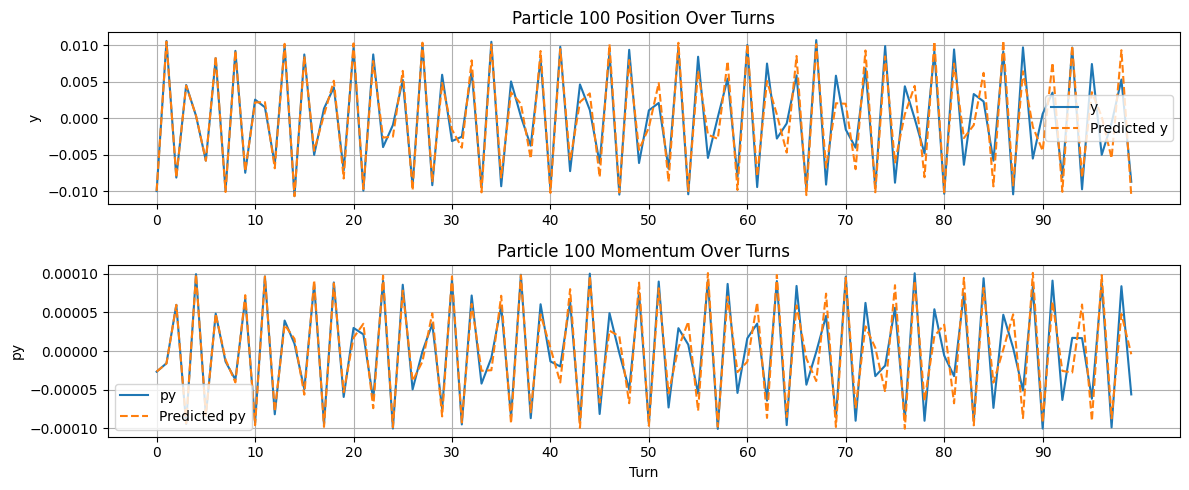

In [80]:
index = 100  # Change this to visualize different particles
turns = np.arange(100)

compare_pred_act_y(index, turns)

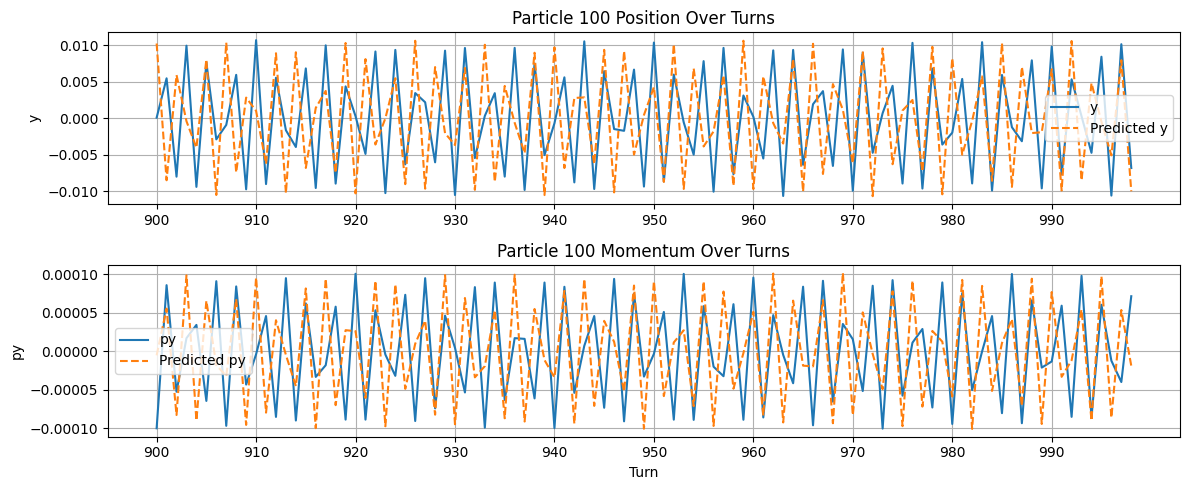

In [88]:
index = 100  # Change this to visualize different particles
turns = np.arange(900, 999)

compare_pred_act_y(index, turns)

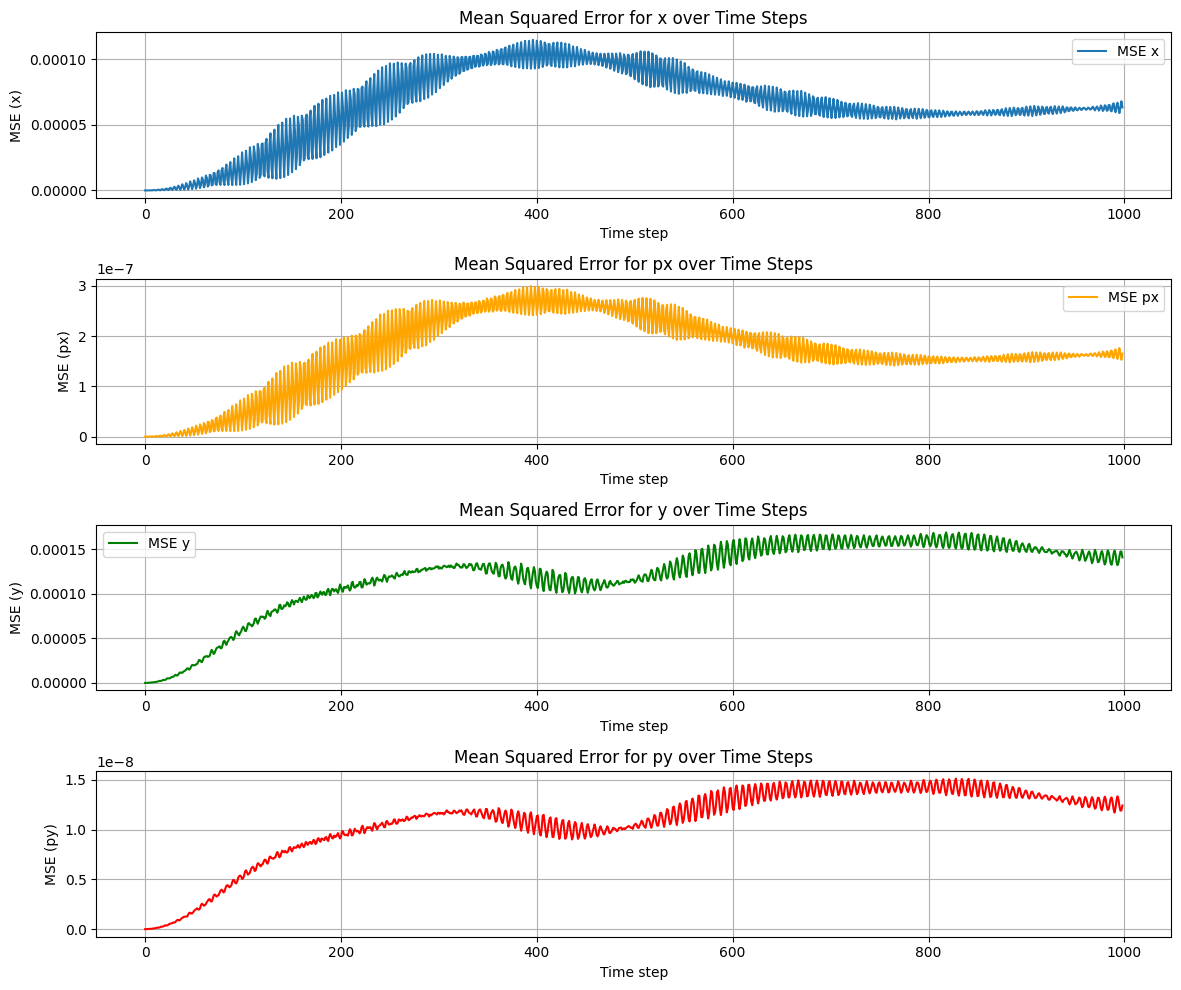

In [74]:
# pred: shape (num_particles, num_timesteps, 2)
# x_xp_test: shape (num_timesteps, num_particles, 2)
# Let's transpose x_xp_test to (num_particles, num_timesteps, 2) for comparison
x_xp_test_aligned = np.transpose(test, (1, 0, 2))

# Compute MSE at each time step for x and px separately
mse_x = np.mean((pred[:, :, 0] - x_xp_test_aligned[:, :, 0]) ** 2, axis=0)
mse_px = np.mean((pred[:, :, 2] - x_xp_test_aligned[:, :, 2]) ** 2, axis=0)
mse_y = np.mean((pred[:, :, 1] - x_xp_test_aligned[:, :, 1]) ** 2, axis=0)
mse_py = np.mean((pred[:, :, 3] - x_xp_test_aligned[:, :, 3]) ** 2, axis=0)

# Plot both on subplots
plt.figure(figsize=(12, 10))

plt.subplot(4, 1, 1)
plt.plot(mse_x, label='MSE x')
plt.xlabel('Time step')
plt.ylabel('MSE (x)')
plt.title('Mean Squared Error for x over Time Steps')
plt.grid()
plt.legend()

plt.subplot(4, 1, 2)
plt.plot(mse_px, label='MSE px', color='orange')
plt.xlabel('Time step')
plt.ylabel('MSE (px)')
plt.title('Mean Squared Error for px over Time Steps')
plt.grid()
plt.legend()

plt.subplot(4, 1, 3)
plt.plot(mse_y, label='MSE y', color='green')
plt.xlabel('Time step')
plt.ylabel('MSE (y)')
plt.title('Mean Squared Error for y over Time Steps')
plt.grid()
plt.legend()

plt.subplot(4, 1, 4)
plt.plot(mse_py, label='MSE py', color='red')
plt.xlabel('Time step')
plt.ylabel('MSE (py)')
plt.title('Mean Squared Error for py over Time Steps')
plt.grid()

plt.tight_layout()
plt.show()

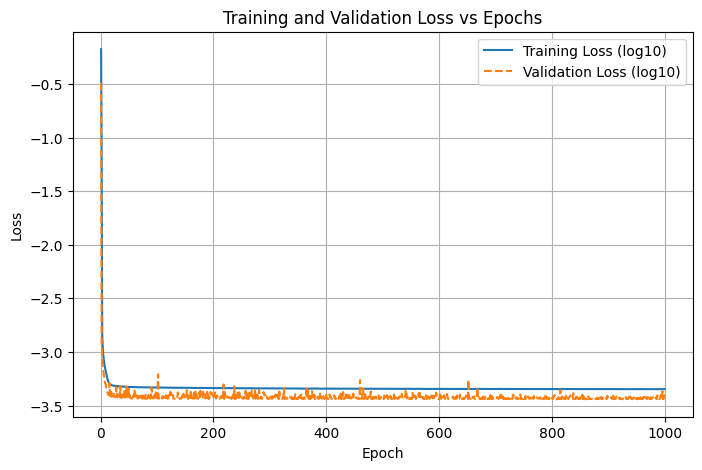

In [61]:
# Load the loss arrays
train_loss = np.load('training_losses1.npy')
val_loss = np.load('validation_losses1.npy')

epochs = np.arange(1, len(train_loss) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, np.log10(train_loss), label='Training Loss (log10)', color='C0')
plt.plot(epochs, np.log10(val_loss), label='Validation Loss (log10)', color='C1', linestyle='--')
plt.ylabel('log10(Loss)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss vs Epochs')
plt.legend()
plt.grid()
plt.show()

In [46]:
import PyNAFF as pnf

In [47]:
# x
print(pnf.naff(test[:500, index, 0], turns=500, nterms=1, skipTurns=0, getFullSpectrum=False, window=1))
print(pnf.naff(test[500:, index, 0], turns=499, nterms=1, skipTurns=0, getFullSpectrum=False, window=1))
print(pnf.naff(pred[index, :500, 0].squeeze(), turns=500, nterms=1, skipTurns=0, getFullSpectrum=False, window=1))
print(pnf.naff(pred[index, 500:, 0].squeeze(), turns=499, nterms=1, skipTurns=0, getFullSpectrum=False, window=1))


[[ 0.          0.37913731  0.00607577  0.00525368 -0.00305186]]
[[ 0.          0.3791373   0.00607415 -0.00604682  0.0005755 ]]
[[ 0.          0.37856354  0.00589525  0.00498213 -0.00315156]]
[[0.         0.37856269 0.00589687 0.00219783 0.00547199]]


In [63]:
# y
print(pnf.naff(test[:500, index, 3], turns=500, nterms=1, skipTurns=0, getFullSpectrum=False, window=1))
print(pnf.naff(test[500:, index, 3], turns=499, nterms=1, skipTurns=0, getFullSpectrum=False, window=1))
print(pnf.naff(pred[index, :500, 3].squeeze(), turns=500, nterms=1, skipTurns=0, getFullSpectrum=False, window=1))
print(pnf.naff(pred[index, 500:, 3].squeeze(), turns=499, nterms=1, skipTurns=0, getFullSpectrum=False, window=1))


[[ 0.00000000e+00  4.23730903e-01  5.12635242e-05  3.54378749e-05
  -3.70419483e-05]]
[[ 0.00000000e+00  4.23730894e-01  5.12635375e-05 -4.20477282e-06
  -5.10908032e-05]]
[[ 0.00000000e+00  4.24016116e-01  5.09577421e-05  3.67194340e-05
  -3.53323456e-05]]
[[ 0.00000000e+00  4.24016645e-01  5.09769266e-05  3.84644812e-05
  -3.34534114e-05]]
